# Traffic Sign Detection and Recognition (TSDR)
### APS360 Final Project — Benjamin Noto

This notebook implements a Traffic Sign Detection and Recognition system using the German Traffic Sign Recognition Benchmark (GTSRB) dataset. It trains a CNN model and compares it against an SVM+HOG baseline.

## 1. Setup & Imports

In [1]:
# Install required packages (uncomment if running fresh)
!pip install torch torchvision scikit-learn scikit-image matplotlib seaborn tqdm pandas

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import GTSRB

# Scikit-learn (baseline)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from skimage.feature import hog
from skimage.color import rgb2yuv
from skimage.transform import resize

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Data Loading & Exploration

In [3]:
# Class names for the 43 GTSRB categories
CLASS_NAMES = [
    'Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)',
    'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)',
    'End of speed limit (80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)',
    'No passing', 'No passing for vehicles over 3.5 metric tons',
    'Right-of-way at the next intersection', 'Priority road', 'Yield', 'Stop',
    'No vehicles', 'Vehicles over 3.5 metric tons prohibited', 'No entry',
    'General caution', 'Dangerous curve to the left', 'Dangerous curve to the right',
    'Double curve', 'Bumpy road', 'Slippery road',
    'Road narrows on the right', 'Road work', 'Traffic signals', 'Pedestrians',
    'Children crossing', 'Bicycles crossing', 'Beware of ice/snow',
    'Wild animals crossing', 'End of all speed and passing limits',
    'Turn right ahead', 'Turn left ahead', 'Ahead only',
    'Go straight or right', 'Go straight or left', 'Keep right', 'Keep left',
    'Roundabout mandatory', 'End of no passing',
    'End of no passing by vehicles over 3.5 metric tons'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 43


In [4]:
DATA_DIR = './data'
IMG_SIZE = 32  # resize all images to 32x32

# Download GTSRB via torchvision (no transform yet — we'll inspect raw data first)
raw_train = GTSRB(root=DATA_DIR, split='train', download=True)
raw_test  = GTSRB(root=DATA_DIR, split='test',  download=True)

print(f"Training samples : {len(raw_train)}")
print(f"Test samples     : {len(raw_test)}")

100%|██████████| 187M/187M [00:14<00:00, 12.7MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 14.1MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 196kB/s]


Training samples : 26640
Test samples     : 12630


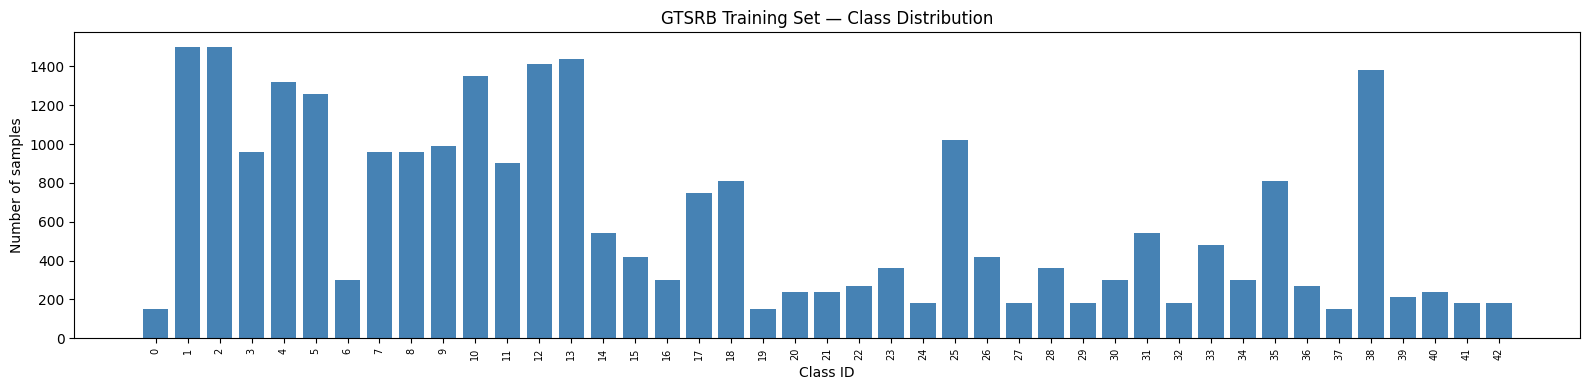


Min samples per class : 150
Max samples per class : 1500
Mean samples per class: 619.5


In [5]:
# ── Class distribution ──────────────────────────────────────────────────────
train_labels = [raw_train[i][1] for i in range(len(raw_train))]
class_counts = Counter(train_labels)

plt.figure(figsize=(16, 4))
plt.bar(range(NUM_CLASSES), [class_counts[c] for c in range(NUM_CLASSES)], color='steelblue')
plt.xlabel('Class ID')
plt.ylabel('Number of samples')
plt.title('GTSRB Training Set — Class Distribution')
plt.xticks(range(NUM_CLASSES), rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"\nMin samples per class : {min(class_counts.values())}")
print(f"Max samples per class : {max(class_counts.values())}")
print(f"Mean samples per class: {np.mean(list(class_counts.values())):.1f}")

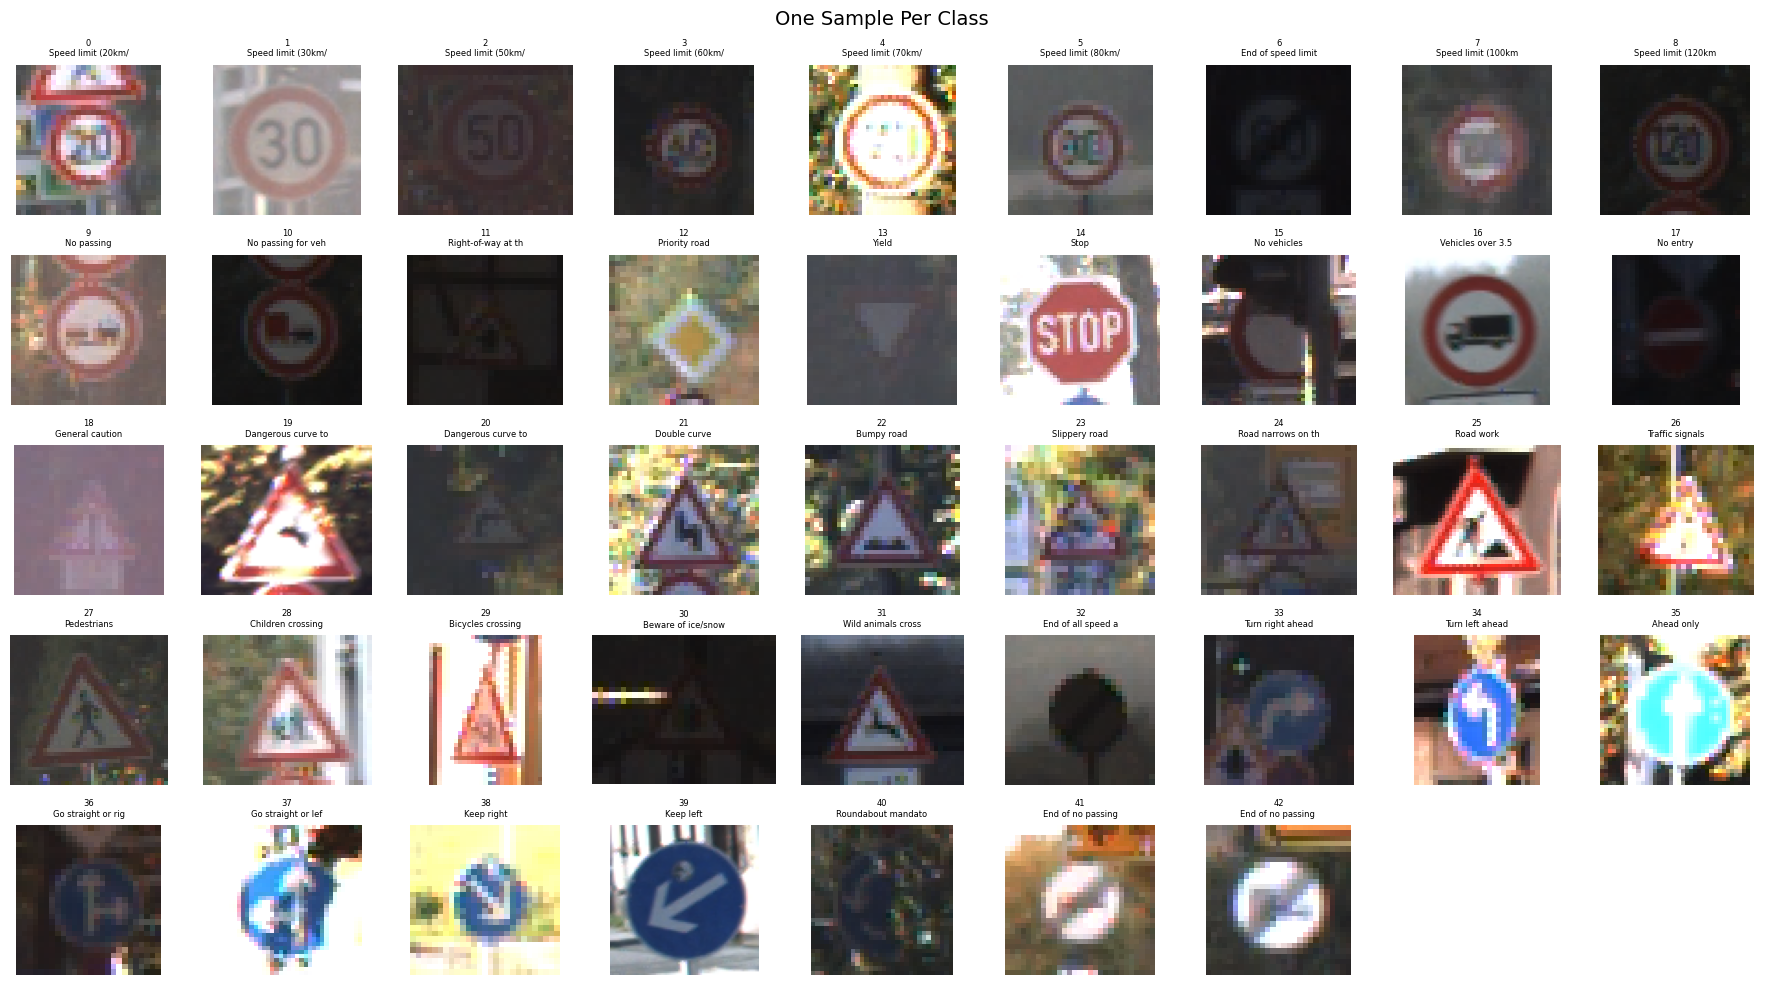

In [6]:
# ── Sample images from each class ───────────────────────────────────────────
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()
shown = set()
idx = 0
for i in range(len(raw_train)):
    img, label = raw_train[i]
    if label not in shown:
        axes[idx].imshow(img)
        axes[idx].set_title(f'{label}\n{CLASS_NAMES[label][:18]}', fontsize=6)
        axes[idx].axis('off')
        shown.add(label)
        idx += 1
    if len(shown) == NUM_CLASSES:
        break
for a in axes[idx:]:
    a.axis('off')
plt.suptitle('One Sample Per Class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Augmentation

In [7]:
# ── Normalisation statistics (ImageNet-style, computed on GTSRB) ────────────
MEAN = (0.3403, 0.3121, 0.3214)
STD  = (0.2724, 0.2608, 0.2669)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # ── Augmentation ──────────────────────────────────────────────────────
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),  # motion blur proxy
    # ── To tensor & normalise ─────────────────────────────────────────────
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined.")

Transforms defined.


In [8]:
# ── Datasets ─────────────────────────────────────────────────────────────────
full_train = GTSRB(root=DATA_DIR, split='train', download=False, transform=train_transform)
test_ds    = GTSRB(root=DATA_DIR, split='test',  download=False, transform=val_transform)

# 80/20 train-validation split
n_val   = int(0.2 * len(full_train))
n_train = len(full_train) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train  : {len(train_ds):>6}")
print(f"Val    : {len(val_ds):>6}")
print(f"Test   : {len(test_ds):>6}")

Train  :  21312
Val    :   5328
Test   :  12630


In [9]:
# ── Weighted sampler to handle class imbalance ───────────────────────────────
train_targets = [full_train[i][1] for i in train_ds.indices]
class_counts_arr = np.array([class_counts[c] for c in range(NUM_CLASSES)], dtype=float)
class_weights = 1.0 / class_counts_arr
sample_weights = np.array([class_weights[t] for t in train_targets])
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_ds),
    replacement=True
)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 333


## 4. Model Architecture — CNN

In [10]:
class TSDR_CNN(nn.Module):
    """
    Multi-scale CNN inspired by Sermanet & LeCun (2011).

    Architecture:
      Input  : (B, 3, 32, 32)
      Stage 1: Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
      Stage 2: Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
      Stage 3: Conv(128) → BN → ReLU → Conv(128) → BN → ReLU → MaxPool → Dropout(0.25)
      Classifier: Flatten → FC(256) → BN → ReLU → Dropout(0.5) → FC(43)

    Multi-scale skip: stage-1 pool output is flattened and concatenated
    with stage-2 pool output before the classifier, allowing the model
    to use both fine-grained and abstract features (as in the paper).
    """

    def __init__(self, num_classes: int = 43):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.25),
            )

        self.stage1 = conv_block(3,   32)   # → (B, 32, 16, 16)
        self.stage2 = conv_block(32,  64)   # → (B, 64,  8,  8)
        self.stage3 = conv_block(64, 128)   # → (B,128,  4,  4)

        # Multi-scale: flatten stage1 (32*16*16=8192) + stage3 (128*4*4=2048) = 10240
        self.classifier = nn.Sequential(
            nn.Linear(32 * 16 * 16 + 128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        s1 = self.stage1(x)           # (B, 32, 16, 16)
        s2 = self.stage2(s1)          # (B, 64,  8,  8)
        s3 = self.stage3(s2)          # (B,128,  4,  4)
        # Multi-scale concatenation
        feat = torch.cat([s1.flatten(1), s3.flatten(1)], dim=1)
        return self.classifier(feat)


model = TSDR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(model)

Trainable parameters: 2,920,715
TSDR_CNN(
  (stage1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (stage2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## 5. Training the CNN

In [11]:
# Hyperparameters
EPOCHS    = 30
LR        = 1e-3
WD        = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("Optimizer, loss, and scheduler set up.")

Optimizer, loss, and scheduler set up.


In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

In [13]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
CKPT = 'tsdr_best.pth'

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    v_loss, v_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), CKPT)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc*100:.2f}% | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc*100:.2f}%"
          + (" ✓ best" if v_acc == best_val_acc else ""))

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")

Epoch 01/30 | Train Loss: 2.6641 Acc: 32.11% | Val Loss: 1.8449 Acc: 60.47% ✓ best
Epoch 02/30 | Train Loss: 1.6460 Acc: 69.20% | Val Loss: 1.2535 Acc: 83.48% ✓ best
Epoch 03/30 | Train Loss: 1.2433 Acc: 85.98% | Val Loss: 1.0001 Acc: 94.09% ✓ best
Epoch 04/30 | Train Loss: 1.0862 Acc: 92.22% | Val Loss: 0.9181 Acc: 97.09% ✓ best
Epoch 05/30 | Train Loss: 1.0078 Acc: 94.88% | Val Loss: 0.8677 Acc: 97.92% ✓ best
Epoch 06/30 | Train Loss: 0.9570 Acc: 96.32% | Val Loss: 0.8356 Acc: 98.42% ✓ best
Epoch 07/30 | Train Loss: 0.9287 Acc: 96.82% | Val Loss: 0.8623 Acc: 97.54%
Epoch 08/30 | Train Loss: 0.9004 Acc: 97.78% | Val Loss: 0.8161 Acc: 98.87% ✓ best
Epoch 09/30 | Train Loss: 0.8812 Acc: 98.20% | Val Loss: 0.8019 Acc: 99.02% ✓ best
Epoch 10/30 | Train Loss: 0.8715 Acc: 98.10% | Val Loss: 0.7871 Acc: 99.14% ✓ best
Epoch 11/30 | Train Loss: 0.8563 Acc: 98.56% | Val Loss: 0.7765 Acc: 99.17% ✓ best
Epoch 12/30 | Train Loss: 0.8491 Acc: 98.64% | Val Loss: 0.7714 Acc: 99.46% ✓ best
Epoch 13/30

## 6. Training Curves

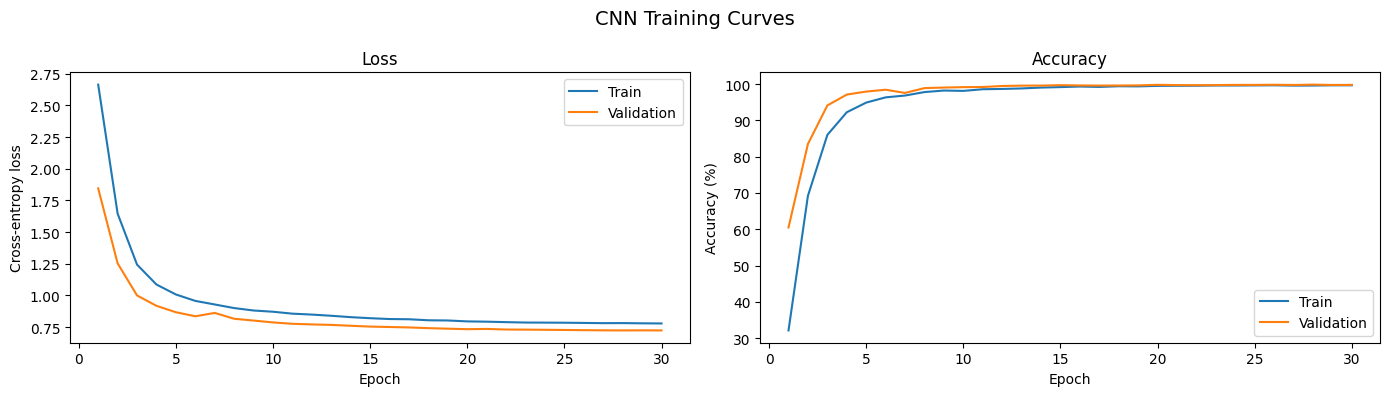

In [14]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'],   label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.legend()

ax2.plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train')
ax2.plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.suptitle('CNN Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 7. Baseline Model — SVM with HOG Features

In [15]:
def extract_hog_features(dataset, img_size=32, max_samples=None):
    """
    Convert images to YUV and extract HOG features.
    Uses only the Y (luminance) channel, as is common in traffic sign literature.
    """
    features, labels = [], []
    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    for i in tqdm(range(n), desc='Extracting HOG'):
        img, label = dataset[i]
        img_arr = np.array(img.resize((img_size, img_size))) / 255.0
        yuv = rgb2yuv(img_arr)
        y_channel = yuv[:, :, 0]  # luminance
        feat = hog(
            y_channel,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False
        )
        features.append(feat)
        labels.append(label)
    return np.array(features), np.array(labels)


print("Extracting HOG features for training set (this may take a few minutes)...")
X_train_hog, y_train_hog = extract_hog_features(raw_train)
print(f"HOG feature shape: {X_train_hog.shape}")

Extracting HOG features for training set (this may take a few minutes)...


Extracting HOG: 100%|██████████| 26640/26640 [00:18<00:00, 1402.33it/s]


HOG feature shape: (26640, 324)


In [16]:
print("Extracting HOG features for test set...")
X_test_hog, y_test_hog = extract_hog_features(raw_test)

# Train SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'))
])

print("Training SVM (this may take several minutes)...")
svm_pipeline.fit(X_train_hog, y_train_hog)

baseline_preds = svm_pipeline.predict(X_test_hog)
baseline_acc   = accuracy_score(y_test_hog, baseline_preds)
print(f"\nSVM + HOG Test Accuracy: {baseline_acc * 100:.2f}%")

Extracting HOG features for test set...


Extracting HOG: 100%|██████████| 12630/12630 [00:08<00:00, 1446.50it/s]


Training SVM (this may take several minutes)...

SVM + HOG Test Accuracy: 81.60%


## 8. CNN Evaluation on Test Set

In [17]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))

@torch.inference_mode()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

cnn_preds, cnn_labels = get_predictions(model, test_loader, DEVICE)
cnn_acc = accuracy_score(cnn_labels, cnn_preds)
print(f"CNN Test Accuracy: {cnn_acc * 100:.2f}%")

CNN Test Accuracy: 98.70%


## 9. Quantitative Results

In [18]:
# Summary table
print("=" * 45)
print(f"{'Model':<25} {'Test Accuracy':>15}")
print("=" * 45)
print(f"{'SVM + HOG (baseline)':<25} {baseline_acc*100:>14.2f}%")
print(f"{'CNN (ours)':<25} {cnn_acc*100:>14.2f}%")
print("-" * 45)
print(f"{'Sermanet & LeCun (2011)':<25} {'99.17':>15}%")
print(f"{'Ciresan et al. (2012)':<25} {'99.46':>15}%")
print("=" * 45)

Model                       Test Accuracy
SVM + HOG (baseline)               81.60%
CNN (ours)                         98.70%
---------------------------------------------
Sermanet & LeCun (2011)             99.17%
Ciresan et al. (2012)               99.46%


In [19]:
# Per-class classification report
print("\nCNN — Per-Class Classification Report")
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES, digits=3))


CNN — Per-Class Classification Report
                                                    precision    recall  f1-score   support

                              Speed limit (20km/h)      1.000     1.000     1.000        60
                              Speed limit (30km/h)      0.988     0.994     0.991       720
                              Speed limit (50km/h)      0.991     0.995     0.993       750
                              Speed limit (60km/h)      0.961     0.987     0.974       450
                              Speed limit (70km/h)      1.000     0.989     0.995       660
                              Speed limit (80km/h)      0.981     0.994     0.987       630
                       End of speed limit (80km/h)      1.000     0.927     0.962       150
                             Speed limit (100km/h)      0.996     0.998     0.997       450
                             Speed limit (120km/h)      0.998     1.000     0.999       450
                                        

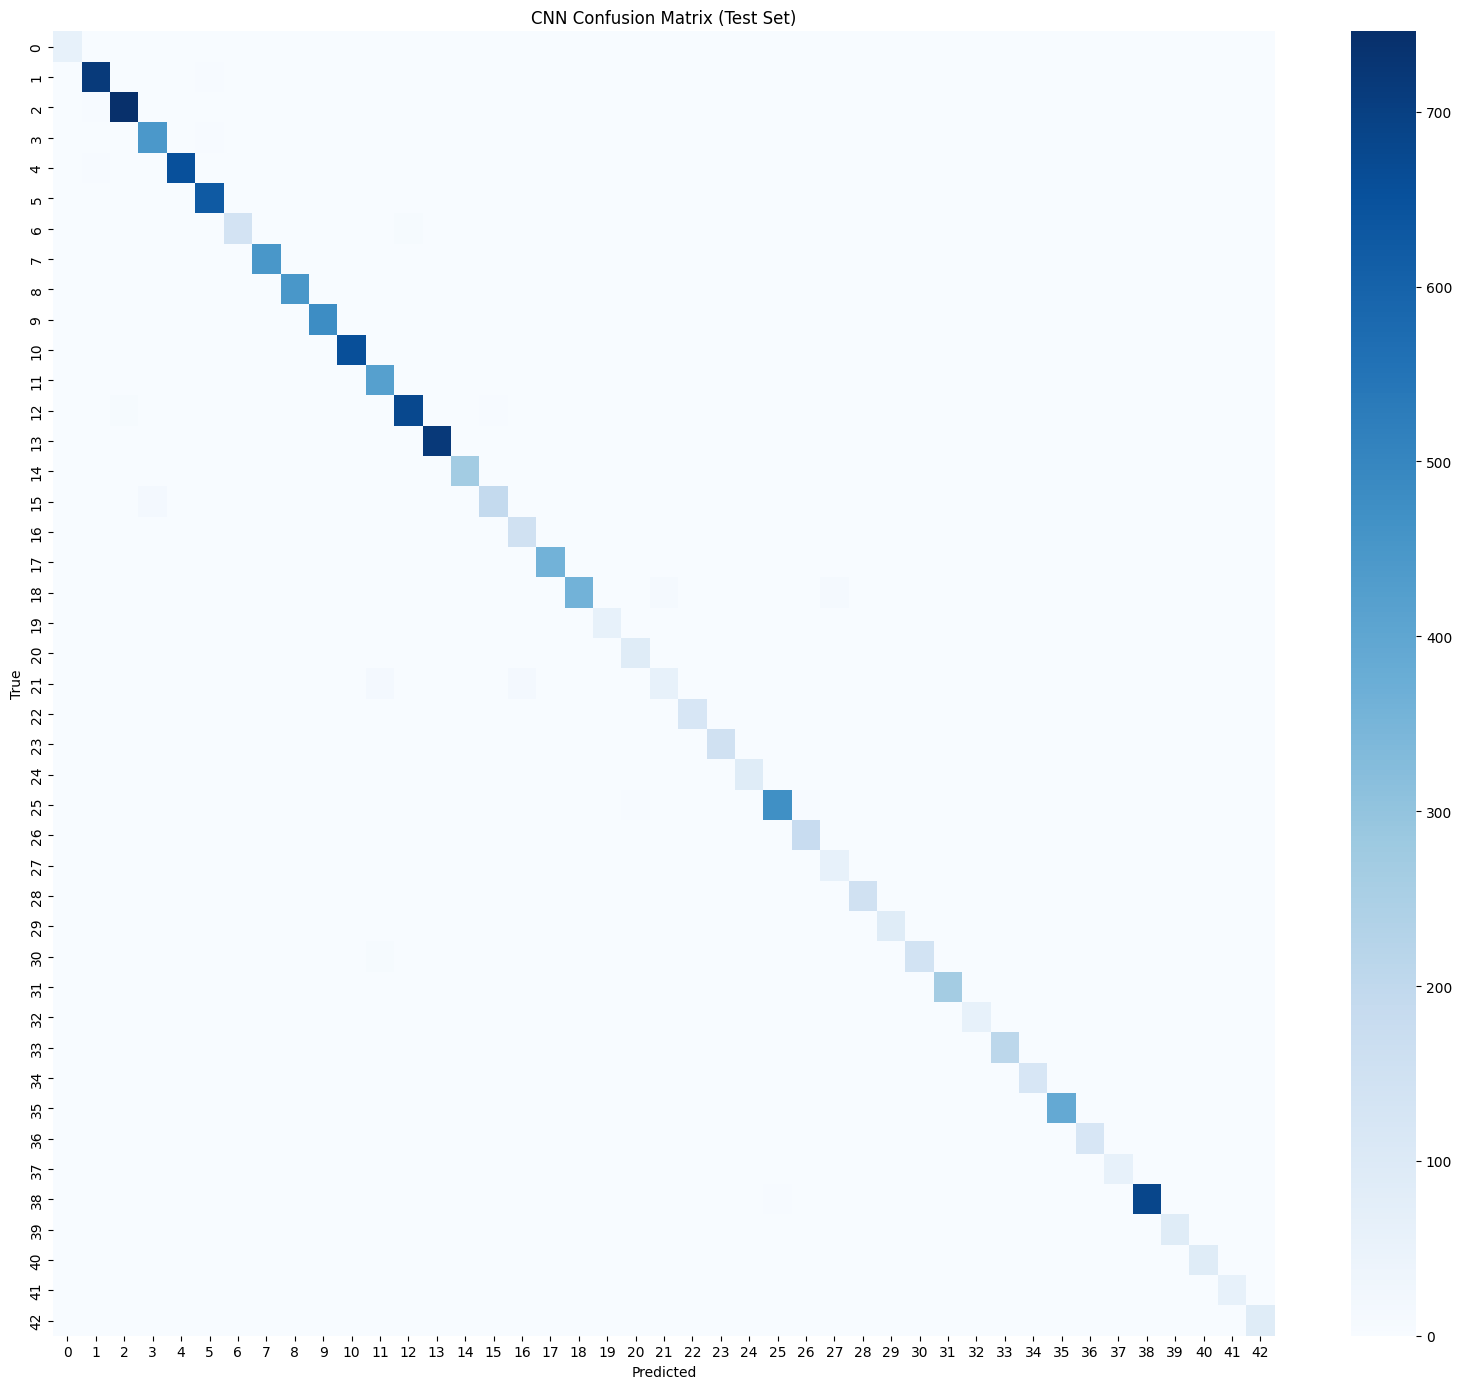

In [20]:
# Confusion matrix (CNN)
cm = confusion_matrix(cnn_labels, cnn_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 10. Qualitative Results

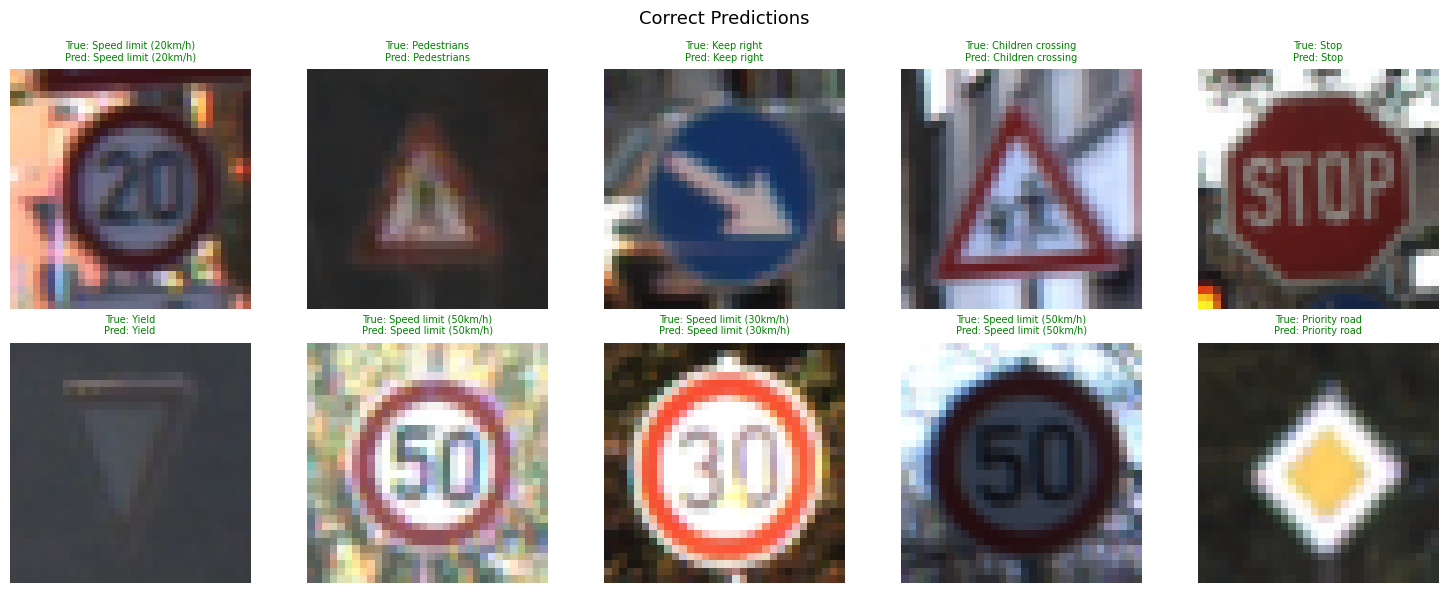

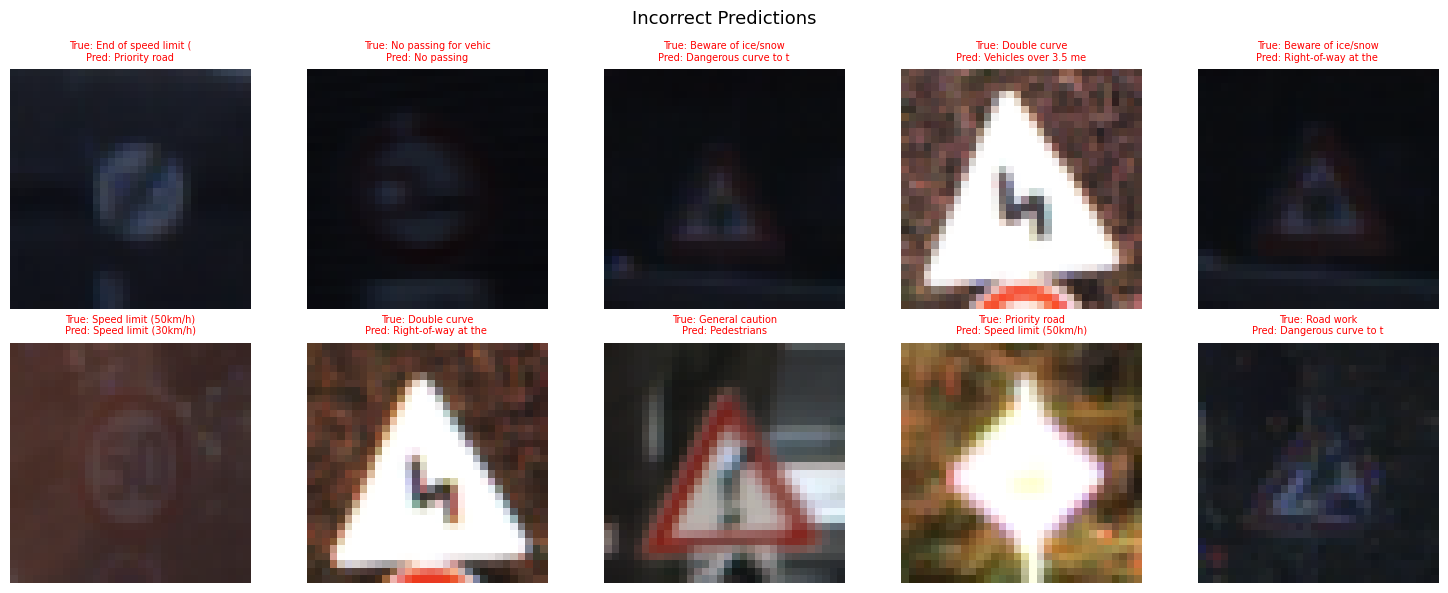

In [21]:
def denormalize(tensor, mean=MEAN, std=STD):
    """Reverse normalization for display."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


# Correct predictions
correct_idx = np.where(cnn_preds == cnn_labels)[0]
wrong_idx   = np.where(cnn_preds != cnn_labels)[0]

def show_samples(indices, title, n=10):
    chosen = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for ax, i in zip(axes, chosen):
        img_tensor, _ = test_ds[i]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        ax.imshow(img)
        pred_name = CLASS_NAMES[cnn_preds[i]][:20]
        true_name = CLASS_NAMES[cnn_labels[i]][:20]
        color = 'green' if cnn_preds[i] == cnn_labels[i] else 'red'
        ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=7, color=color)
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

show_samples(correct_idx, 'Correct Predictions')
show_samples(wrong_idx,   'Incorrect Predictions')

In [22]:
# Per-class accuracy (worst vs best classes)
per_class_acc = []
for c in range(NUM_CLASSES):
    mask = cnn_labels == c
    if mask.sum() > 0:
        per_class_acc.append((c, (cnn_preds[mask] == cnn_labels[mask]).mean()))

per_class_acc.sort(key=lambda x: x[1])
print("5 Hardest Classes:")
for c, acc in per_class_acc[:5]:
    print(f"  Class {c:2d} ({CLASS_NAMES[c][:35]:<35}) : {acc*100:.1f}%")

print("\n5 Easiest Classes:")
for c, acc in per_class_acc[-5:]:
    print(f"  Class {c:2d} ({CLASS_NAMES[c][:35]:<35}) : {acc*100:.1f}%")

5 Hardest Classes:
  Class 21 (Double curve                       ) : 66.7%
  Class 15 (No vehicles                        ) : 91.0%
  Class 18 (General caution                    ) : 92.3%
  Class  6 (End of speed limit (80km/h)        ) : 92.7%
  Class 30 (Beware of ice/snow                 ) : 93.3%

5 Easiest Classes:
  Class 35 (Ahead only                         ) : 100.0%
  Class 36 (Go straight or right               ) : 100.0%
  Class 37 (Go straight or left                ) : 100.0%
  Class 41 (End of no passing                  ) : 100.0%
  Class 42 (End of no passing by vehicles over ) : 100.0%
